In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("everything works")

everything works


In [4]:
import pandas as pd
import io

data = """year,catholics,total_population,pct_catholic,diocesan_priests,religious_priests,total_priests,catholics_per_priest,permanent_deacons,male_religious,female_religious,parishes
1959,275581,617800,44.6,177,132,309,891,0,193,564,73
1966,298607,713100,41.9,234,142,376,794,0,233,949,87
1970,322188,797700,40.4,356,155,511,630,0,184,891,84
1976,331734,826800,40.1,198,138,336,987,0,162,754,84
1980,340441,837000,40.7,224,110,334,1019,19,110,694,86
1990,354020,826000,42.9,238,95,333,1063,50,100,710,90
1999,360918,833315,43.3,259,70,329,1097,83,0,487,88
2000,363246,838362,43.3,226,68,294,1235,83,68,489,88
2001,364685,841334,43.3,231,60,291,1253,86,60,466,87
2002,362569,882567,41.1,237,58,295,1229,87,58,481,87
2003,365992,885368,41.3,241,62,303,1207,93,62,439,87
2004,410304,896202,45.8,268,44,312,1315,94,45,356,87
2006,410304,903291,45.4,279,46,325,1262,99,46,395,87
2012,479000,955000,50.2,240,32,272,1761,103,32,330,82
2015,420000,939904,44.7,199,32,231,1818,99,34,298,82
2018,438664,953618,46.0,198,34,232,1890,114,35,288,82
2020,441000,956570,46.1,191,24,215,2051,93,25,288,80
2022,439000,952978,46.1,185,18,203,2162,88,19,176,80
2023,441000,957419,46.1,188,12,200,2205,92,12,174,73
"""

df = pd.read_csv(io.StringIO(data))
print(df.to_string())

    year  catholics  total_population  pct_catholic  diocesan_priests  religious_priests  total_priests  catholics_per_priest  permanent_deacons  male_religious  female_religious  parishes
0   1959     275581            617800          44.6               177                132            309                   891                  0             193               564        73
1   1966     298607            713100          41.9               234                142            376                   794                  0             233               949        87
2   1970     322188            797700          40.4               356                155            511                   630                  0             184               891        84
3   1976     331734            826800          40.1               198                138            336                   987                  0             162               754        84
4   1980     340441            837000          40.7    

In [5]:
print(df.to_string())

    year  catholics  total_population  pct_catholic  diocesan_priests  religious_priests  total_priests  catholics_per_priest  permanent_deacons  male_religious  female_religious  parishes
0   1959     275581            617800          44.6               177                132            309                   891                  0             193               564        73
1   1966     298607            713100          41.9               234                142            376                   794                  0             233               949        87
2   1970     322188            797700          40.4               356                155            511                   630                  0             184               891        84
3   1976     331734            826800          40.1               198                138            336                   987                  0             162               754        84
4   1980     340441            837000          40.7    

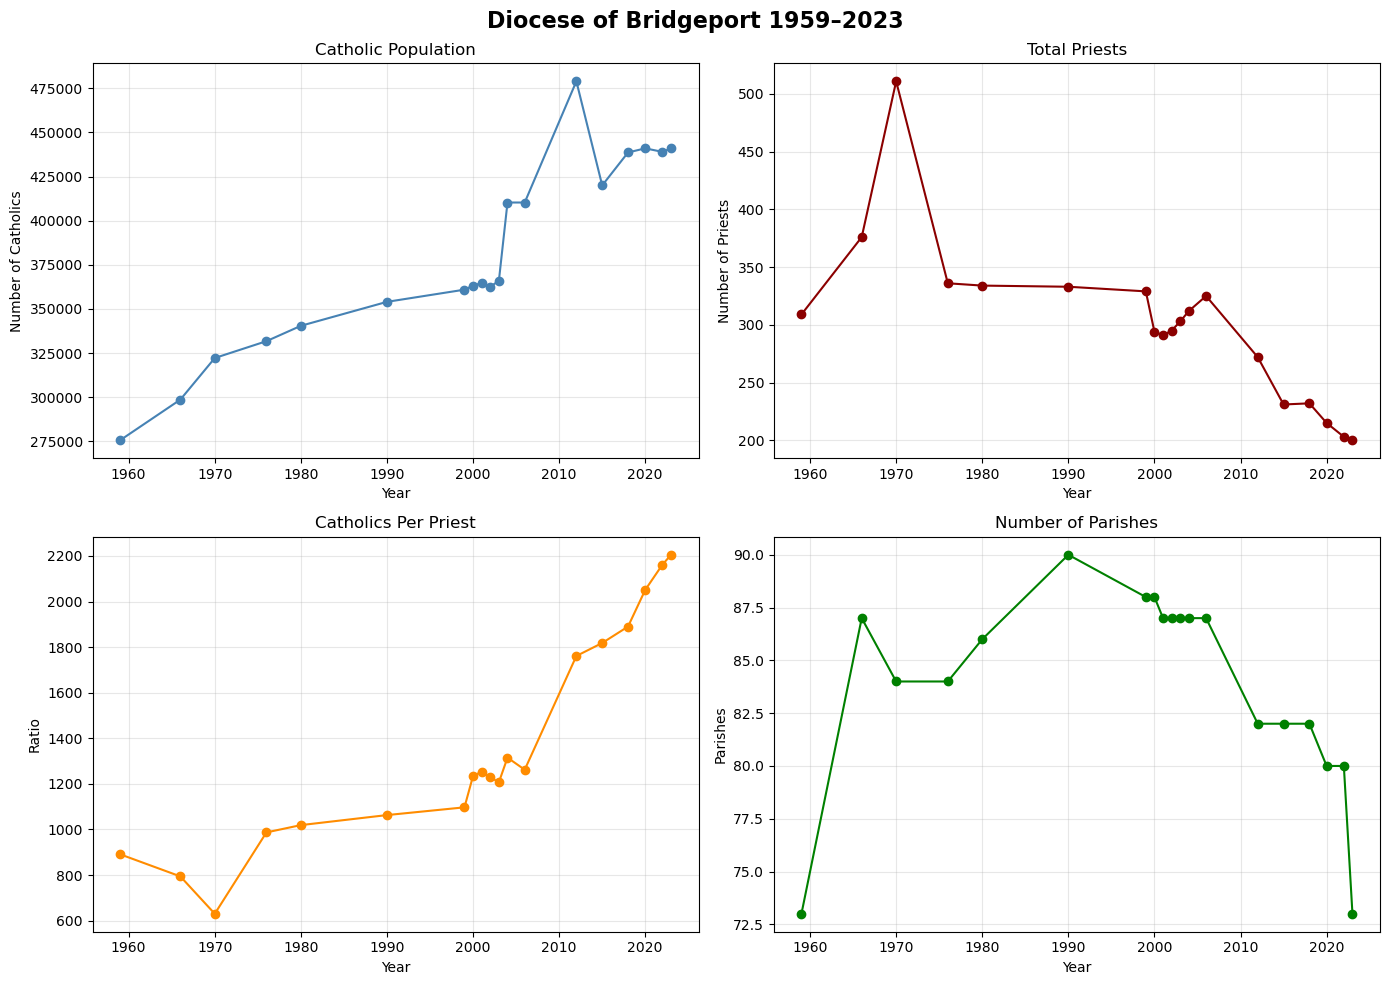

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diocese of Bridgeport 1959–2023', fontsize=16, fontweight='bold')

# Catholics over time
axes[0,0].plot(df['year'], df['catholics'], marker='o', color='steelblue')
axes[0,0].set_title('Catholic Population')
axes[0,0].set_ylabel('Number of Catholics')

# Total priests over time
axes[0,1].plot(df['year'], df['total_priests'], marker='o', color='darkred')
axes[0,1].set_title('Total Priests')
axes[0,1].set_ylabel('Number of Priests')

# Catholics per priest over time
axes[1,0].plot(df['year'], df['catholics_per_priest'], marker='o', color='darkorange')
axes[1,0].set_title('Catholics Per Priest')
axes[1,0].set_ylabel('Ratio')

# Parishes over time
axes[1,1].plot(df['year'], df['parishes'], marker='o', color='green')
axes[1,1].set_title('Number of Parishes')
axes[1,1].set_ylabel('Parishes')

for ax in axes.flat:
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# How much has each metric changed from 1959 to 2023?
start = df[df['year'] == 1959].iloc[0]
end = df[df['year'] == 2023].iloc[0]

metrics = ['catholics', 'total_priests', 'parishes', 'catholics_per_priest']
for m in metrics:
    change = ((end[m] - start[m]) / start[m]) * 100
    print(f"{m}: {change:+.1f}%")

catholics: +60.0%
total_priests: -35.3%
parishes: +0.0%
catholics_per_priest: +147.5%


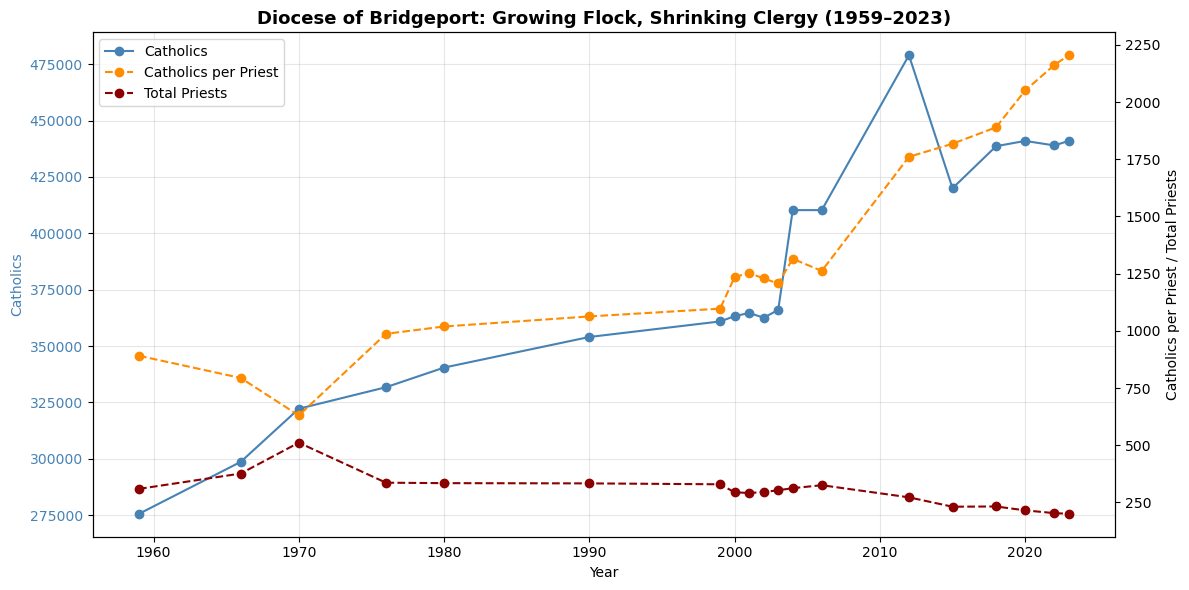

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis - Catholics
ax1.set_xlabel('Year')
ax1.set_ylabel('Catholics', color='steelblue')
ax1.plot(df['year'], df['catholics'], marker='o', color='steelblue', label='Catholics')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Right axis 1 - Catholics per priest
ax2 = ax1.twinx()
ax2.set_ylabel('Catholics per Priest / Total Priests', color='black')
ax2.plot(df['year'], df['catholics_per_priest'], marker='o', color='darkorange',
         linestyle='--', label='Catholics per Priest')
ax2.plot(df['year'], df['total_priests'], marker='o', color='darkred',
         linestyle='--', label='Total Priests')
ax2.tick_params(axis='y')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Diocese of Bridgeport: Growing Flock, Shrinking Clergy (1959–2023)',
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()